# Data Validation

This notebook validates the raw credit card fraud dataset before cleaning, feature engineering, and model training. The goal is to identify structural issues, data quality risks, and corrective actions required for the next stage of the project.

## 1. Validation Objectives

This notebook focuses on the following validation tasks:

- confirm that the required dataset schema is present
- verify that expected columns are numeric where required
- check missing values and duplicate rows
- validate target integrity for the `Class` column
- review numeric range constraints for `Time` and `Amount`
- summarize which checks pass and which issues require cleaning

In [18]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "src").exists():
            return candidate
    raise RuntimeError("Project root not found. Open the notebook from inside the project.")

project_root = find_project_root(Path.cwd())
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.config import AMOUNT_COLUMN, PCA_COLUMNS, PROJECT_ROOT, TARGET_COLUMN, TIME_COLUMN
from src.data.data_loader import load_raw_data
from src.data.data_validation import REQUIRED_COLUMNS, DataValidationError, validate_raw_data

NOTEBOOK_TABLES_DIR = PROJECT_ROOT / "reports" / "tables" / "03_data_validation"
NOTEBOOK_FIGURES_DIR = PROJECT_ROOT / "reports" / "figures" / "03_data_validation"
NOTEBOOK_TABLES_DIR.mkdir(parents=True, exist_ok=True)
NOTEBOOK_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Imports OK")
print(f"  TARGET_COLUMN : {TARGET_COLUMN}")
print(f"  Required cols : {len(REQUIRED_COLUMNS)}")
print(f"  Tables dir    : {NOTEBOOK_TABLES_DIR}")
print(f"  Figures dir   : {NOTEBOOK_FIGURES_DIR}")

Imports OK
  TARGET_COLUMN : Class
  Required cols : 31
  Tables dir    : /Users/mmubashir/VCode/Credit-Card-Fraud-Detection/reports/tables/03_data_validation
  Figures dir   : /Users/mmubashir/VCode/Credit-Card-Fraud-Detection/reports/figures/03_data_validation


## 2. Load Raw Data

In [19]:
df = load_raw_data()

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 3. Schema Validation

In [20]:
schema_validation = pd.DataFrame({
    "column": REQUIRED_COLUMNS,
    "present": [column in df.columns for column in REQUIRED_COLUMNS]
})
schema_validation.to_csv(NOTEBOOK_TABLES_DIR / "schema_validation.csv", index=False)
schema_validation

,column,present
0,Time,True
1,V1,True
2,V2,True
3,V3,True
4,V4,True
5,V5,True
6,V6,True
7,V7,True
8,V8,True
9,V9,True


In [21]:
missing_required_columns = sorted(set(REQUIRED_COLUMNS) - set(df.columns))
print("Missing required columns:", missing_required_columns if missing_required_columns else "None")

Missing required columns: None


## 4. Data Type Validation

In [22]:
columns_to_check = [TIME_COLUMN, *PCA_COLUMNS, AMOUNT_COLUMN, TARGET_COLUMN]
dtype_validation = pd.DataFrame({
    "column": columns_to_check,
    "dtype": [str(df[column].dtype) for column in columns_to_check],
    "non_numeric_after_coercion": [int(pd.to_numeric(df[column], errors="coerce").isna().sum()) for column in columns_to_check]
})
dtype_validation.to_csv(NOTEBOOK_TABLES_DIR / "dtype_validation.csv", index=False)
dtype_validation

,column,dtype,non_numeric_after_coercion
0,Time,float64,0
1,V1,float64,0
2,V2,float64,0
3,V3,float64,0
4,V4,float64,0
5,V5,float64,0
6,V6,float64,0
7,V7,float64,0
8,V8,float64,0
9,V9,float64,0


## 5. Missing Value Validation

In [23]:
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(4)
})
missing_summary.to_csv(NOTEBOOK_TABLES_DIR / "missing_value_validation.csv")
missing_summary[missing_summary["missing_count"] > 0].sort_values("missing_count", ascending=False)

,missing_count,missing_percent


## 6. Duplicate Validation

In [24]:
duplicate_mask = df.duplicated(keep=False)
duplicate_rows = df[duplicate_mask].copy()
duplicate_count = int(df.duplicated().sum())

duplicate_summary = pd.DataFrame({
    "metric": ["duplicate_rows"],
    "value": [duplicate_count]
})
duplicate_summary.to_csv(NOTEBOOK_TABLES_DIR / "duplicate_validation_summary.csv", index=False)
duplicate_summary

,metric,value
0,duplicate_rows,1081


In [25]:
duplicate_rows.head(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
32,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0
33,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0
34,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0
35,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0
112,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
113,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
114,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
115,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
220,145.0,-2.420413,1.947885,0.553646,0.983069,-0.281518,2.408958,-1.401613,-0.188299,0.675878,...,1.213826,-1.238620,0.006927,-1.724222,0.239603,-0.313703,-0.188281,0.119831,6.00,0
221,145.0,-2.420413,1.947885,0.553646,0.983069,-0.281518,2.408958,-1.401613,-0.188299,0.675878,...,1.213826,-1.238620,0.006927,-1.724222,0.239603,-0.313703,-0.188281,0.119831,6.00,0


In [26]:
if not duplicate_rows.empty:
    duplicate_class_distribution = pd.DataFrame({
        "count": duplicate_rows[TARGET_COLUMN].value_counts().sort_index(),
        "percent": (duplicate_rows[TARGET_COLUMN].value_counts(normalize=True).sort_index() * 100).round(4)
    })
else:
    duplicate_class_distribution = pd.DataFrame(columns=["count", "percent"])

duplicate_class_distribution.to_csv(NOTEBOOK_TABLES_DIR / "duplicate_class_distribution.csv")
duplicate_class_distribution

,count,percent
Class,,
0,1822,98.274
1,32,1.726


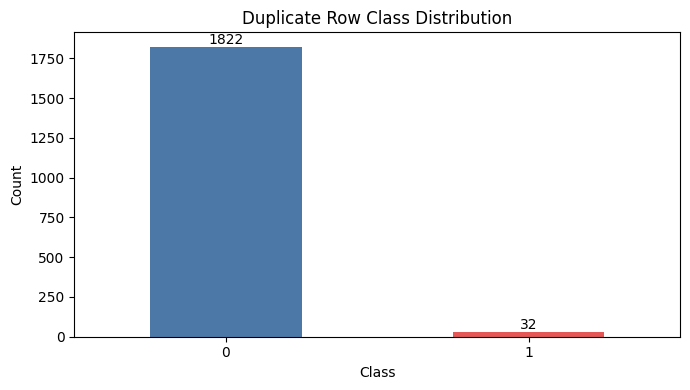

In [27]:
if not duplicate_class_distribution.empty:
    ax = duplicate_class_distribution["count"].plot(kind="bar", color=["#4C78A8", "#E45756"], figsize=(7, 4))
    ax.set_title("Duplicate Row Class Distribution")
    ax.set_xlabel("Class")
    ax.set_ylabel("Count")
    ax.set_xticklabels([str(idx) for idx in duplicate_class_distribution.index], rotation=0)
    for i, value in enumerate(duplicate_class_distribution["count"].values):
        ax.text(i, value, f"{value}", ha="center", va="bottom")
    plt.tight_layout()
    plt.savefig(NOTEBOOK_FIGURES_DIR / "duplicate_class_distribution.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("No duplicate rows found.")

## 7. Target Validation

In [28]:
target_validation = pd.DataFrame({
    "count": df[TARGET_COLUMN].value_counts().sort_index(),
    "percent": (df[TARGET_COLUMN].value_counts(normalize=True).sort_index() * 100).round(4)
})
target_validation.index.name = TARGET_COLUMN
target_validation.to_csv(NOTEBOOK_TABLES_DIR / "target_validation.csv")
target_validation

,count,percent
Class,,
0,284315,99.8273
1,492,0.1727


In [29]:
unique_target_values = sorted(df[TARGET_COLUMN].dropna().unique().tolist())
print("Unique target values:", unique_target_values)

Unique target values: [0, 1]


## 8. Range and Rule Checks

In [30]:
range_checks = pd.DataFrame([
    {
        "check": "time_non_negative",
        "violations": int((pd.to_numeric(df[TIME_COLUMN], errors="coerce") < 0).sum())
    },
    {
        "check": "amount_non_negative",
        "violations": int((pd.to_numeric(df[AMOUNT_COLUMN], errors="coerce") < 0).sum())
    }
])
range_checks.to_csv(NOTEBOOK_TABLES_DIR / "range_rule_checks.csv", index=False)
range_checks

,check,violations
0,time_non_negative,0
1,amount_non_negative,0


In [31]:
extreme_values_summary = pd.DataFrame({
    "column": [TIME_COLUMN, AMOUNT_COLUMN],
    "min": [df[TIME_COLUMN].min(), df[AMOUNT_COLUMN].min()],
    "max": [df[TIME_COLUMN].max(), df[AMOUNT_COLUMN].max()],
    "mean": [df[TIME_COLUMN].mean(), df[AMOUNT_COLUMN].mean()]
})
extreme_values_summary.to_csv(NOTEBOOK_TABLES_DIR / "extreme_values_summary.csv", index=False)
extreme_values_summary

,column,min,max,mean
0,Time,0.0,172792.00,94813.859575
1,Amount,0.0,25691.16,88.349619


## 9. Validation Status

In [32]:
try:
    validate_raw_data(df)
    if duplicate_count > 0:
        overall_validation_status = "PASS WITH WARNINGS"
        validation_message = "Raw data passes schema and value checks, but duplicate rows require cleaning before modeling."
    else:
        overall_validation_status = "PASS"
        validation_message = "Raw data passed the implemented validation checks."
except DataValidationError as error:
    overall_validation_status = "FAIL"
    validation_message = str(error)

validation_status = pd.DataFrame([
    {"check": "required_columns", "status": "PASS" if not missing_required_columns else "FAIL"},
    {"check": "missing_values", "status": "PASS" if int(df.isna().sum().sum()) == 0 else "FAIL"},
    {"check": "duplicate_rows", "status": "FAIL" if duplicate_count > 0 else "PASS"},
    {"check": "target_values", "status": "PASS" if set(unique_target_values).issubset({0, 1}) else "FAIL"},
    {"check": "time_non_negative", "status": "PASS" if int((pd.to_numeric(df[TIME_COLUMN], errors="coerce") < 0).sum()) == 0 else "FAIL"},
    {"check": "amount_non_negative", "status": "PASS" if int((pd.to_numeric(df[AMOUNT_COLUMN], errors="coerce") < 0).sum()) == 0 else "FAIL"},
    {"check": "overall_validation", "status": overall_validation_status}
])
validation_status.to_csv(NOTEBOOK_TABLES_DIR / "validation_status_summary.csv", index=False)
validation_status

,check,status
0,required_columns,PASS
1,missing_values,PASS
2,duplicate_rows,FAIL
3,target_values,PASS
4,time_non_negative,PASS
5,amount_non_negative,PASS
6,overall_validation,PASS WITH WARNINGS


## 10. Why These Checks Matter for Fraud Detection

These validation checks matter because fraud detection is highly sensitive to subtle data-quality problems. Schema validation confirms that the model will receive the expected predictors, target validation ensures the binary fraud label is trustworthy, and missing-value checks reduce the risk of silent preprocessing errors. Duplicate detection is especially important because repeated transactions can distort class frequencies, bias exploratory analysis, and artificially inflate model performance if the same record appears across training and evaluation splits. The dataset is also extremely imbalanced, so that imbalance should be treated as a modeling risk to manage carefully with evaluation strategy, resampling choices, and threshold tuning rather than as a data error to remove.

## 11. Validation Issue Summary

In [33]:
minority_class_percent = (df[TARGET_COLUMN].value_counts(normalize=True).sort_index() * 100).min().round(4)

validation_issue_summary = pd.DataFrame([
    {
        "issue": "Schema validity",
        "severity": "Low",
        "impact_on_model": "Expected fraud-detection fields are present, so feature extraction and training can proceed on the intended schema.",
        "action_in_next_notebook": "Preserve column names and data types during cleaning."
    },
    {
        "issue": "Missing values",
        "severity": "Low",
        "impact_on_model": "No immediate risk of null-driven failures or inconsistent imputations in downstream steps.",
        "action_in_next_notebook": "Reconfirm after duplicate handling and any new transformations."
    },
    {
        "issue": "Target validity",
        "severity": "Low",
        "impact_on_model": "Binary labels are consistent with supervised fraud classification.",
        "action_in_next_notebook": "Protect the target column from unintended remapping or leakage."
    },
    {
        "issue": "Duplicate rows",
        "severity": "High",
        "impact_on_model": "Duplicates can bias class frequencies, skew validation metrics, and leak repeated records across splits.",
        "action_in_next_notebook": "Identify and remove or justify duplicates before feature engineering and model training."
    },
    {
        "issue": "Class imbalance",
        "severity": "High",
        "impact_on_model": f"The minority fraud class is only about {minority_class_percent}% of records, so accuracy alone may be misleading and the model may under-detect fraud.",
        "action_in_next_notebook": "Keep the imbalance intact in cleaned data and plan imbalance-aware evaluation and modeling choices later."
    }
])

validation_issue_summary.to_csv(NOTEBOOK_TABLES_DIR / "validation_issue_summary.csv", index=False)
validation_issue_summary


,issue,severity,impact_on_model,action_in_next_notebook
0,Schema validity,Low,"Expected fraud-detection fields are present, s...",Preserve column names and data types during cl...
1,Missing values,Low,No immediate risk of null-driven failures or i...,Reconfirm after duplicate handling and any new...
2,Target validity,Low,Binary labels are consistent with supervised f...,Protect the target column from unintended rema...
3,Duplicate rows,High,"Duplicates can bias class frequencies, skew va...",Identify and remove or justify duplicates befo...
4,Class imbalance,High,The minority fraud class is only about 0.1727%...,Keep the imbalance intact in cleaned data and ...


## 12. Validation Conclusion

The raw dataset is structurally valid for fraud modeling, but duplicate records are a material data-quality issue that must be resolved before cleaning, feature engineering, and model training. In addition, the extreme class imbalance should be preserved carefully and handled during modeling rather than treated as a data error. In summary, the schema is valid, there are no missing values, the target is valid, and duplicates must be handled before modeling.

In [34]:
validation_report = f"""# Validation Report\n\n## Validation Summary\n\n- Overall validation status: {overall_validation_status}\n- Validation message: {validation_message}\n- Missing required columns: {missing_required_columns if missing_required_columns else 'None'}\n- Total missing values: {int(df.isna().sum().sum())}\n- Duplicate rows: {duplicate_count}\n- Unique target values: {unique_target_values}\n\n## Why These Checks Matter for Fraud Detection\n\nSchema validation confirms that downstream feature engineering and training use the expected structure. Target validation ensures the binary fraud label is reliable for supervised learning. Missing-value checks reduce the risk of silent preprocessing failures. Duplicate detection matters because repeated records can distort class frequencies, inflate metrics, and leak across train-test splits. The extreme class imbalance is not a data error, but it is a modeling risk that must be handled carefully during evaluation and training.\n\n## Key Findings\n\n- The schema is valid for the expected fraud detection workflow.\n- No missing values were detected in the raw dataset.\n- The target column uses valid binary labels.\n- Duplicate rows are present and must be handled before modeling.\n- The class imbalance is substantial and should be managed during modeling rather than removed as a validation issue.\n\n## Validation Issue Summary\n\n| issue | severity | impact on model | action in next notebook |\n| --- | --- | --- | --- |\n| Schema validity | Low | Expected fraud-detection fields are present, so feature extraction and training can proceed on the intended schema. | Preserve column names and data types during cleaning. |\n| Missing values | Low | No immediate risk of null-driven failures or inconsistent imputations in downstream steps. | Reconfirm after duplicate handling and any new transformations. |\n| Target validity | Low | Binary labels are consistent with supervised fraud classification. | Protect the target column from unintended remapping or leakage. |\n| Duplicate rows | High | Duplicates can bias class frequencies, skew validation metrics, and leak repeated records across splits. | Identify and remove or justify duplicates before feature engineering and model training. |\n| Class imbalance | High | The minority fraud class represents a very small share of observations, so accuracy alone may be misleading and the model may under-detect fraud. | Keep the imbalance intact in cleaned data and plan imbalance-aware evaluation and modeling choices later. |\n\n## Final Judgment\n\nThe raw dataset is structurally valid for fraud modeling, but duplicate records are a material data-quality issue that must be resolved before cleaning, feature engineering, and model training. In addition, the extreme class imbalance should be preserved carefully and handled during modeling rather than treated as a data error.\n\n## Saved Tables\n\n- `reports/tables/03_data_validation/schema_validation.csv`\n- `reports/tables/03_data_validation/dtype_validation.csv`\n- `reports/tables/03_data_validation/missing_value_validation.csv`\n- `reports/tables/03_data_validation/duplicate_validation_summary.csv`\n- `reports/tables/03_data_validation/duplicate_class_distribution.csv`\n- `reports/tables/03_data_validation/target_validation.csv`\n- `reports/tables/03_data_validation/range_rule_checks.csv`\n- `reports/tables/03_data_validation/extreme_values_summary.csv`\n- `reports/tables/03_data_validation/validation_status_summary.csv`\n- `reports/tables/03_data_validation/validation_issue_summary.csv`\n- `reports/tables/03_data_validation/validation_report.md`\n\n## Saved Figures\n\n- `reports/figures/03_data_validation/duplicate_class_distribution.png`\n"""

report_path = NOTEBOOK_TABLES_DIR / "validation_report.md"
report_path.write_text(validation_report, encoding="utf-8")
print(f"Validation report saved to: {report_path}")

Validation report saved to: /Users/mmubashir/VCode/Credit-Card-Fraud-Detection/reports/tables/03_data_validation/validation_report.md


## 13. Next Step

The next notebook should be `04_data_cleaning.ipynb`. It should handle duplicate removal and any additional cleaning actions identified during validation, then save the cleaned dataset to the interim data folder.